In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing as pp
import sklearn.metrics as ms
from sklearn.model_selection import train_test_split
from warnings import filterwarnings
filterwarnings('ignore') 


In [3]:
df_train=pd.read_csv(r"C:\Users\Lenovo\Desktop\Datas\fraudTrain.csv")
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


**Data Cleaning**

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [5]:
df_train.drop(columns=['Unnamed: 0'],axis=1,inplace=True)

In [6]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
df_train.isna().sum()
#There is no any null value in this dataset

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [8]:
df_train['is_fraud'].value_counts()

"""
is_fraud
0    1289169
1       7506
"""

'\nis_fraud\n0    1289169\n1       7506\n'

**Feature Engineering**

In [9]:
dropping_colms=['cc_num','first','last','street','city','state','zip','trans_num','unix_time']
#We are droping these columns ,cuz that columns can cause to much noise ,overfitting to our models,also some of them are not useful for our models training and predictions
df_train.drop(columns=dropping_colms,axis=1,inplace=True)
df_train

,trans_date_trans_time,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,36.011293,-82.048315,0
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,43.150704,-112.154481,0
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1967-01-12,47.034331,-112.561071,0
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,fraud_Reichel Inc,entertainment,15.56,M,37.7175,-112.4777,258,Geoscientist,1961-11-24,36.841266,-111.690765,0
1296671,2020-06-21 12:12:19,fraud_Abernathy and Sons,food_dining,51.70,M,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,38.906881,-78.246528,0
1296672,2020-06-21 12:12:32,fraud_Stiedemann Ltd,food_dining,105.93,M,32.9396,-105.8189,899,Naval architect,1967-08-30,33.619513,-105.130529,0
1296673,2020-06-21 12:13:36,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,42.788940,-103.241160,0


In [10]:
#We are calculating Age for each customer to determine relations between  age targets  and is_fraud columns
df_train['dob']=pd.to_datetime(df_train['dob'])
df_train['age']= 2026-df_train['dob'].dt.year
df_train.drop(columns=['dob'],inplace=True)
print("Columns are updated")

Columns are updated


In [11]:
# We will find the distances between customers locations and transaction coordinations
# I will use Haversine formula to find this distances
def haversine_formula(lat1,lon1,lat_merch,lon_merch):
    lat1,lon1,lat_merch,lon_merch = map(np.radians,[lat1,lon1,lat_merch,lon_merch])

    dlat=lat_merch-lat1
    dlon=lon_merch-lon1

    a= np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat_merch) * np.cos(lat_merch)*np.sin(dlon/2.0)**2
    c= 2 *np.arcsin(np.sqrt(a))

    r= 6371 # The Radius of Earth
    return c*r

df_train['distance_km']=haversine_formula(df_train['lat'],df_train['long'],df_train['merch_lat'],df_train['merch_long'])

In [12]:
df_train['is_online']=df_train['category'].apply(
    lambda x: 1 if 'net' in x or 'online' in x else 0
)

In [13]:
df_train.groupby('is_fraud')['distance_km'].agg(['mean','max','std'])

,mean,max,std
is_fraud,,,
0,72.689885,150.134011,28.641050
1,72.846557,141.068949,28.279949


The average distance for both normal and fraudulent transactions is remarkably similar (~72.7 km). This suggests that distance alone is not a strong 'smoking gun' for fraud detection in this dataset. It indicates that fraudsters are sophisticated and tend to operate within the victim's typical geographical range. Therefore, the model should rely on the interaction between distance, transaction amount (amt), and time of day (trans_hour) to identify anomalies

In [14]:
df_train['trans_date_trans_time']=pd.to_datetime(df_train['trans_date_trans_time'])
df_train['trans_hour']=df_train['trans_date_trans_time'].dt.hour
df_train['trans_day']=df_train['trans_date_trans_time'].dt.dayofweek
df_train['trans_month']=df_train['trans_date_trans_time'].dt.month
df_train['merchant'] = df_train['merchant'].str.replace('fraud_', '')

In [15]:
df_train['is_night']=df_train['trans_hour'].apply(lambda x: 1 if x<=6 else 0)
# Transactions occurring between 00:00 and 06:00 are often considered anomalous as they fall outside typical consumer behavior. I created the is_night binary feature to highlight these high-risk hours, allowing the model to more easily capture time-based fraudulent patterns

In [16]:
df_train.groupby('is_fraud')['is_night'].mean()
# It shows 35.6%  of frauds happen at nights

is_fraud
0    0.228408
1    0.356115
Name: is_night, dtype: float64

In [17]:
df_train['amt'].describe()

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64

In [18]:
dropping_colms2=['trans_date_trans_time','lat','long','merch_lat','merch_long']
df_train.drop(columns=dropping_colms2,axis=1,inplace=True)

In [19]:
df_train

,merchant,category,amt,gender,city_pop,job,is_fraud,age,distance_km,is_online,trans_hour,trans_day,trans_month,is_night
0,"Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",0,38,70.765850,1,0,1,1,1
1,"Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,0,48,30.194577,0,0,1,1,1
2,Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,0,64,108.109468,0,0,1,1,1
3,"Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,0,59,93.712292,0,0,1,1,1
4,Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,0,40,69.794714,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,Reichel Inc,entertainment,15.56,M,258,Geoscientist,0,65,115.639672,0,12,6,6,0
1296671,Abernathy and Sons,food_dining,51.70,M,100,"Production assistant, television",0,47,68.880008,0,12,6,6,0
1296672,Stiedemann Ltd,food_dining,105.93,M,899,Naval architect,0,59,95.527726,0,12,6,6,0
1296673,"Reinger, Weissnat and Strosin",food_dining,74.90,M,1126,Volunteer coordinator,0,46,79.380500,0,12,6,6,0


In [20]:
df_train

,merchant,category,amt,gender,city_pop,job,is_fraud,age,distance_km,is_online,trans_hour,trans_day,trans_month,is_night
0,"Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",0,38,70.765850,1,0,1,1,1
1,"Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,0,48,30.194577,0,0,1,1,1
2,Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,0,64,108.109468,0,0,1,1,1
3,"Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,0,59,93.712292,0,0,1,1,1
4,Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,0,40,69.794714,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,Reichel Inc,entertainment,15.56,M,258,Geoscientist,0,65,115.639672,0,12,6,6,0
1296671,Abernathy and Sons,food_dining,51.70,M,100,"Production assistant, television",0,47,68.880008,0,12,6,6,0
1296672,Stiedemann Ltd,food_dining,105.93,M,899,Naval architect,0,59,95.527726,0,12,6,6,0
1296673,"Reinger, Weissnat and Strosin",food_dining,74.90,M,1126,Volunteer coordinator,0,46,79.380500,0,12,6,6,0


In [21]:
df_train

,merchant,category,amt,gender,city_pop,job,is_fraud,age,distance_km,is_online,trans_hour,trans_day,trans_month,is_night
0,"Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",0,38,70.765850,1,0,1,1,1
1,"Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,0,48,30.194577,0,0,1,1,1
2,Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,0,64,108.109468,0,0,1,1,1
3,"Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,0,59,93.712292,0,0,1,1,1
4,Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,0,40,69.794714,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,Reichel Inc,entertainment,15.56,M,258,Geoscientist,0,65,115.639672,0,12,6,6,0
1296671,Abernathy and Sons,food_dining,51.70,M,100,"Production assistant, television",0,47,68.880008,0,12,6,6,0
1296672,Stiedemann Ltd,food_dining,105.93,M,899,Naval architect,0,59,95.527726,0,12,6,6,0
1296673,"Reinger, Weissnat and Strosin",food_dining,74.90,M,1126,Volunteer coordinator,0,46,79.380500,0,12,6,6,0


**Label Encoding**

In [22]:
# I will encode "category" and "gender" columns
df_train = pd.get_dummies(df_train,columns=['category','gender'],dtype=int,drop_first=True)
df_train.head()

,merchant,amt,city_pop,job,is_fraud,age,distance_km,is_online,trans_hour,trans_day,...,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M
0,"Rippin, Kub and Mann",4.97,3495,"Psychologist, counselling",0,38,70.765850,1,0,1,...,0,0,0,1,0,0,0,0,0,0
1,"Heller, Gutmann and Zieme",107.23,149,Special educational needs teacher,0,48,30.194577,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,Lind-Buckridge,220.11,4154,Nature conservation officer,0,64,108.109468,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,"Kutch, Hermiston and Farrell",45.00,1939,Patent attorney,0,59,93.712292,0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,Keeling-Crist,41.96,99,Dance movement psychotherapist,0,40,69.794714,0,0,1,...,0,0,0,0,1,0,0,0,0,1


In [23]:
import category_encoders as ce

X=df_train.drop('is_fraud',axis=1)
Y=df_train['is_fraud']

x_train,x_test,y_train,y_test= train_test_split(X,Y,test_size=0.20,random_state=42)

encoder = ce.TargetEncoder(cols=['merchant','job'])
x_train=encoder.fit_transform(x_train,y_train)
x_test=encoder.transform(x_test)




In [24]:
scaler=pp.StandardScaler()
cols_to_scale = ['amt','distance_km','city_pop']

x_train[cols_to_scale]= scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale]= scaler.transform(x_test[cols_to_scale])

print("Columns are scaled successfully")


Columns are scaled successfully


In [25]:
x_train.head()

,merchant,amt,city_pop,job,age,distance_km,is_online,trans_hour,trans_day,trans_month,...,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M
330201,0.000000,-0.403002,-0.290721,0.003104,75,-0.384532,0,14,3,6,...,0,0,0,0,0,0,0,0,1,0
798518,0.000000,-0.316720,-0.294342,0.006311,42,1.308112,0,19,1,12,...,0,0,0,0,0,0,0,0,0,0
1260375,0.008895,-0.217680,-0.213328,0.004243,43,-0.374584,0,12,0,6,...,1,0,0,0,0,0,0,0,0,0
412511,0.001385,-0.177508,-0.284366,0.000000,51,-0.054296,1,1,5,7,...,0,0,0,0,0,0,0,0,0,1
344644,0.002773,-0.082573,0.130655,0.003893,34,1.463387,0,23,0,6,...,0,0,1,0,0,0,0,0,0,0


In [26]:
correlation = x_train.merge(y_train,right_index=True,left_index=True).corr()
correlation

,merchant,amt,city_pop,job,age,distance_km,is_online,trans_hour,trans_day,trans_month,...,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M,is_fraud
merchant,1.000000,0.094040,0.000922,0.011150,-0.000202,0.000570,0.568891,-0.357378,0.002114,-0.001778,...,-0.246501,-0.195203,0.343499,-0.114910,-0.159430,0.576938,0.072538,-0.093186,-0.009560,0.073664
amt,0.094040,1.000000,0.005761,0.035859,-0.010699,-0.001672,0.021904,-0.023570,-0.001228,-0.002036,...,-0.024674,-0.024658,0.014425,-0.012630,-0.038898,0.032521,0.018936,0.045892,0.000425,0.220387
city_pop,0.000922,0.005761,1.000000,0.001058,-0.091218,0.013660,0.010387,0.019852,0.002227,0.000218,...,-0.003124,-0.001006,-0.002092,0.003942,0.000608,0.004201,0.010881,-0.002789,-0.028635,0.003165
job,0.011150,0.035859,0.001058,1.000000,0.054883,0.000370,-0.002818,-0.023113,-0.001907,0.002559,...,-0.001585,-0.000194,0.000905,-0.000956,-0.003169,0.003915,0.000004,0.003647,0.046839,0.153767
age,-0.000202,-0.010699,-0.091218,0.054883,1.000000,-0.006319,-0.049954,-0.172573,-0.011558,0.002574,...,0.014295,0.020898,0.002438,-0.028229,0.015554,-0.016326,-0.017495,0.020176,0.005074,0.012054
distance_km,0.000570,-0.001672,0.013660,0.000370,-0.006319,1.000000,0.001116,0.001141,0.000422,0.000029,...,-0.000053,-0.000397,-0.000142,0.000145,-0.000043,0.000332,0.000843,0.001723,-0.003352,0.000098
is_online,0.568891,0.021904,0.010387,-0.002818,-0.049954,0.001116,1.000000,-0.211357,0.001041,-0.000191,...,-0.140786,-0.134326,0.521144,-0.111371,-0.119304,0.655915,-0.136769,-0.078087,-0.014084,0.043318
trans_hour,-0.357378,-0.023570,0.019852,-0.023113,-0.172573,0.001141,-0.211357,1.000000,0.000410,0.000026,...,0.223363,0.213450,-0.167555,-0.080484,0.189333,-0.014065,0.002292,0.124205,-0.037515,0.013594
trans_day,0.002114,-0.001228,0.002227,-0.001907,-0.011558,0.000422,0.001041,0.000410,1.000000,0.039709,...,-0.003089,-0.001146,0.000790,0.003467,0.000447,0.000788,-0.001400,-0.002772,-0.001241,0.001366
trans_month,-0.001778,-0.002036,0.000218,0.002559,0.002574,0.000029,-0.000191,0.000026,0.039709,1.000000,...,0.000654,0.000124,-0.000753,0.001469,0.000329,-0.000424,0.000100,0.001356,0.000494,-0.013047


In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression(penalty='l1',solver='liblinear',class_weight='balanced',random_state=42)
grid_parametres ={"C":[10,100]}
grid_search = GridSearchCV(log_reg,grid_parametres,cv=5,scoring='recall')
grid_search.fit(x_train,y_train)

best_model=grid_search.best_estimator_

print(f'En yaxsi C parametri :{grid_search.best_params_}')

En yaxsi C parametri :{'C': 10}


In [28]:
x_train=pd.DataFrame(x_train,columns=x_train.columns,index=x_train.index)
x_test=pd.DataFrame(x_test,columns=x_test.columns,index=x_test.index)


In [29]:
performance =pd.DataFrame(data=None, index=['BAS','AS'])
performance

""
BAS
AS


In [30]:
def evaluate(model,model_name):
    performance[model_name]= [ms.balanced_accuracy_score(y_test,model.predict(x_test)),
                              ms.accuracy_score(y_test,model.predict(x_test))]
    print(ms.classification_report(y_test,model.predict(x_test)))
    print("--------Balanced Accuracy Score----------")
    print(ms.balanced_accuracy_score(y_test,model.predict(x_test)))
    print("-------Accuracy Score----------")
    print(ms.accuracy_score(y_test,model.predict(x_test)))

pd.options.display.float_format = '{:.2f}'.format

In [31]:
evaluate(grid_search,'log_reg_0.5')


              precision    recall  f1-score   support

           0       1.00      0.89      0.94    257815
           1       0.04      0.82      0.08      1520

    accuracy                           0.89    259335
   macro avg       0.52      0.85      0.51    259335
weighted avg       0.99      0.89      0.93    259335

--------Balanced Accuracy Score----------
0.8509449860518099
-------Accuracy Score----------
0.8856883953187962


In [32]:
cutoff=y_train.mean()
cutoff

np.float64(0.0057705284670407)

In [33]:
prd=(pd.DataFrame(grid_search.predict_proba(x_test))[1]>cutoff).astype(np.int8)
prd.head()

0    1
1    1
2    0
3    1
4    1
Name: 1, dtype: int8

In [34]:
print(ms.classification_report(y_test,prd))
print("-----------Balanced Accuracy Score-----------")
print(ms.balanced_accuracy_score(y_test,prd))
print("----------Accuracy Score-------------")
print(ms.accuracy_score(y_test,prd))

              precision    recall  f1-score   support

           0       1.00      0.12      0.22    257815
           1       0.01      1.00      0.01      1520

    accuracy                           0.13    259335
   macro avg       0.50      0.56      0.12    259335
weighted avg       0.99      0.13      0.22    259335

-----------Balanced Accuracy Score-----------
0.5613928592207591
----------Accuracy Score-------------
0.12792719841132127


While the model achieves a 100% recall by identifying every single fraud case, it suffers from an extremely low precision. By flagging nearly everyone as a fraudster, the model creates excessive 'noise,' leading to poor customer experience and operational inefficiency

In [35]:
performance['Log_reg_57']=[ms.balanced_accuracy_score(y_test,prd),ms.accuracy_score(y_test,prd)]
performance

,log_reg_0.5,Log_reg_57
BAS,0.85,0.56
AS,0.89,0.13


In [36]:
evaluate(best_model,"log_reg_50")

              precision    recall  f1-score   support

           0       1.00      0.89      0.94    257815
           1       0.04      0.82      0.08      1520

    accuracy                           0.89    259335
   macro avg       0.52      0.85      0.51    259335
weighted avg       0.99      0.89      0.93    259335

--------Balanced Accuracy Score----------
0.8509449860518099
-------Accuracy Score----------
0.8856883953187962


In [37]:
performance

,log_reg_0.5,Log_reg_57,log_reg_50
BAS,0.85,0.56,0.85
AS,0.89,0.13,0.89


Random Forest Modelling

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced',random_state=42,n_jobs=1)

In [40]:
rf_model.fit(x_train,y_train)

evaluate(rf_model,"Random_Forest")


              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257815
           1       0.29      0.93      0.44      1520

    accuracy                           0.99    259335
   macro avg       0.64      0.96      0.72    259335
weighted avg       1.00      0.99      0.99    259335

--------Balanced Accuracy Score----------
0.9589803275910818
-------Accuracy Score----------
0.9860605008965238


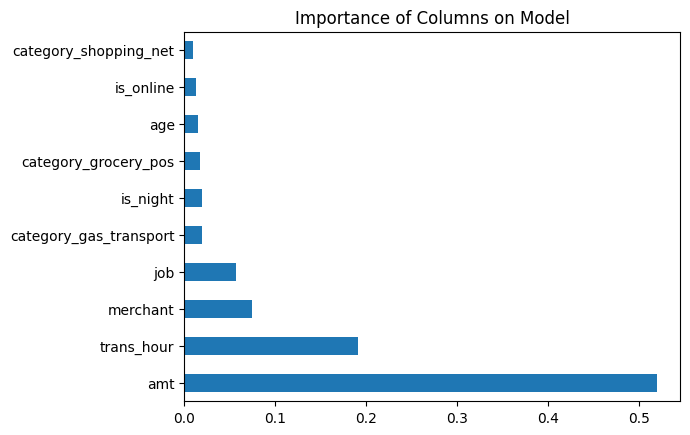

In [42]:
colm_importance = pd.Series(rf_model.feature_importances_,index=x_train.columns)
colm_importance.nlargest(10).plot(kind='barh')
plt.title("Importance of Columns on Model")
plt.show()

In [43]:
performance

,log_reg_0.5,Log_reg_57,log_reg_50,Random_Forest
BAS,0.85,0.56,0.85,0.96
AS,0.89,0.13,0.89,0.99
